In [2]:
import os
import random
import textwrap
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from PIL import Image
import yaml

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    REPO_ROOT = Path(__file__).resolve().parent
except NameError:
    _cwd = Path(".").resolve()
    REPO_ROOT = _cwd if ((_cwd / "data.yaml").exists() or (_cwd / "data").exists()) else _cwd
DATA_ROOT   = REPO_ROOT / "data" / "DATA_CLEAN"
DATA_YAML   = REPO_ROOT / "data.yaml"

IMAGE_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print(f"Repo root : {REPO_ROOT}")
print(f"Data root : {DATA_ROOT}")
print(f"Exists    : {DATA_ROOT.exists()}")

Repo root : D:\My Documents\Desktop\ironhack\labs\m6-04-assessment
Data root : D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data\DATA_CLEAN
Exists    : True


In [3]:
def discover_layout(data_root: Path):
    """
    Returns (image_paths, label_dir_fn) where
    label_dir_fn(img_path) -> expected .txt path for that image.
    """
    images_dir = data_root / "images"
    labels_dir = data_root / "labels"

    if images_dir.exists():
        layout = "split (images/ + labels/)"
        img_paths = sorted(
            p for p in images_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS
        )
        def label_path(img: Path) -> Path:
            rel = img.relative_to(images_dir)
            return labels_dir / rel.with_suffix(".txt")
    else:
        layout = "flat (images & labels in same folder)"
        img_paths = sorted(
            p for p in data_root.rglob("*") if p.suffix.lower() in IMAGE_EXTS
        )
        def label_path(img: Path) -> Path:
            return img.with_suffix(".txt")

    return img_paths, label_path, layout


image_paths, label_path_fn, LAYOUT = discover_layout(DATA_ROOT)

print(f"Layout detected : {LAYOUT}")
print(f"Total images    : {len(image_paths)}")

for p in image_paths[:5]:
    print(f"  {p.relative_to(DATA_ROOT)}  →  label: {label_path_fn(p).relative_to(DATA_ROOT)}")

Layout detected : split (images/ + labels/)
Total images    : 3327
  images\0008ab3d8674f6ca.jpg  →  label: labels\0008ab3d8674f6ca.txt
  images\0013eebbcafa70e5.jpg  →  label: labels\0013eebbcafa70e5.txt
  images\0019edb653711193.jpg  →  label: labels\0019edb653711193.txt
  images\001b61e5094d71cb.jpg  →  label: labels\001b61e5094d71cb.txt
  images\0025cbded55ded0f.jpg  →  label: labels\0025cbded55ded0f.txt


## Task 1

### 1-A · Image & Label Counts + Matching Check

In [4]:
all_label_paths = [label_path_fn(img) for img in image_paths]

images_with_label    = [img for img, lbl in zip(image_paths, all_label_paths) if lbl.exists()]
images_without_label = [img for img, lbl in zip(image_paths, all_label_paths) if not lbl.exists()]

if (DATA_ROOT / "labels").exists():
    all_txt = set((DATA_ROOT / "labels").rglob("*.txt"))
else:
    all_txt = set(DATA_ROOT.rglob("*.txt"))

expected_txts = set(all_label_paths)
orphan_labels = all_txt - expected_txts

print("=" * 50)
print(f"  Total image files          : {len(image_paths):>6}")
print(f"  Total label (.txt) files   : {len(all_txt):>6}")
print("-" * 50)
print(f"  Images WITH  matching label: {len(images_with_label):>6}")
print(f"  Images WITHOUT label       : {len(images_without_label):>6}")
print(f"  Orphan labels (no image)   : {len(orphan_labels):>6}")
print("=" * 50)

if images_without_label:
    print("\n  Images missing a label file (first 10):")
    for p in images_without_label[:10]:
        print(f"   {p.name}")

if orphan_labels:
    print("\n  Orphan label files (first 10):")
    for p in list(orphan_labels)[:10]:
        print(f"   {p.name}")

if not images_without_label and not orphan_labels:
    print("\n  Perfect 1-to-1 match between images and labels.")

  Total image files          :   3327
  Total label (.txt) files   :   3327
--------------------------------------------------
  Images WITH  matching label:   3327
  Images WITHOUT label       :      0
  Orphan labels (no image)   :      0

  Perfect 1-to-1 match between images and labels.


### 1-B · Class Distribution

In [5]:
def _find_yaml():
    candidates = [
        Path(".").resolve() / "data.yaml",
        DATA_ROOT.parent / "data.yaml",
        DATA_ROOT.parent.parent / "data.yaml",
    ]
    return next((p for p in candidates if p.exists()), None)

yaml_path = _find_yaml()
if yaml_path:
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f) or {}
    raw = cfg.get("names", {})
    class_names = {i: n for i, n in enumerate(raw)} if isinstance(raw, list) else raw
    print(f"✅  Loaded class names from {yaml_path}")
else:
    class_names = {}   # will be filled in below after scanning labels
    print("ℹ️  No data.yaml found — class names will be auto-generated from label files")

def get_name(cid: int) -> str:
    return class_names.get(cid, f"class_{cid}")

class_counter: Counter = Counter()
parse_errors = []

for lbl_path in all_label_paths:
    if not lbl_path.exists():
        continue
    try:
        with open(lbl_path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                class_counter[int(parts[0])] += 1
    except Exception as e:
        parse_errors.append((lbl_path.name, str(e)))

if parse_errors:
    print(f"⚠  {len(parse_errors)} label file(s) had parse errors.")

# ── Display table ─────────────────────────────────────────────────────────────
print(f"\n{'Class ID':<10} {'Class Name':<20} {'Object Count':>12}")
print("-" * 44)
total_objects = 0
for cid, count in sorted(class_counter.items()):
    print(f"{cid:<10} {get_name(cid):<20} {count:>12,}")
    total_objects += count
print("-" * 44)
print(f"{'TOTAL':<30} {total_objects:>12,}")

✅  Loaded class names from D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data.yaml

Class ID   Class Name           Object Count
--------------------------------------------
0          class_0                     3,895
--------------------------------------------
TOTAL                                 3,895


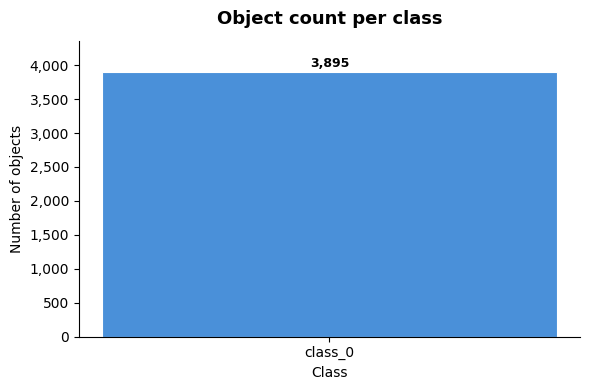

Figure saved → class_distribution.png


In [6]:
if class_counter:
    ids    = sorted(class_counter.keys())
    names  = [get_name(i) for i in ids]
    counts = [class_counter[i] for i in ids]

    fig, ax = plt.subplots(figsize=(max(6, len(ids) * 0.9 + 2), 4))
    bars = ax.bar(names, counts, color="#4A90D9", edgecolor="white", linewidth=0.8)

    for bar, cnt in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            f"{cnt:,}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    ax.set_title("Object count per class", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of objects")
    ax.set_ylim(0, max(counts) * 1.12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved → class_distribution.png")

### 1-C · Image Size Statistics (100 random images)

In [7]:
sample_size = min(100, len(image_paths))
sampled     = random.sample(image_paths, sample_size)

widths, heights = [], []
for img_path in sampled:
    try:
        with Image.open(img_path) as im:
            w, h = im.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        print(f"Could not open {img_path.name}: {e}")

widths  = np.array(widths)
heights = np.array(heights)

print(f"Image size statistics (n={len(widths)} random images)")
print("=" * 46)
print(f"{'Metric':<12} {'Width (px)':>14} {'Height (px)':>14}")
print("-" * 46)
print(f"{'Min':<12} {widths.min():>14,} {heights.min():>14,}")
print(f"{'Max':<12} {widths.max():>14,} {heights.max():>14,}")
print(f"{'Mean':<12} {widths.mean():>14.1f} {heights.mean():>14.1f}")
print(f"{'Median':<12} {np.median(widths):>14.1f} {np.median(heights):>14.1f}")
print(f"{'Std':<12} {widths.std():>14.1f} {heights.std():>14.1f}")
print("=" * 46)

unique_sizes = len(set(zip(widths.tolist(), heights.tolist())))
print(f"\nUnique (W×H) combinations: {unique_sizes}")

Image size statistics (n=100 random images)
Metric           Width (px)    Height (px)
----------------------------------------------
Min                     640            640
Max                   6,000          4,608
Mean                 2624.0         2008.7
Median               2457.0         2027.0
Std                  1342.6         1002.1

Unique (W×H) combinations: 73


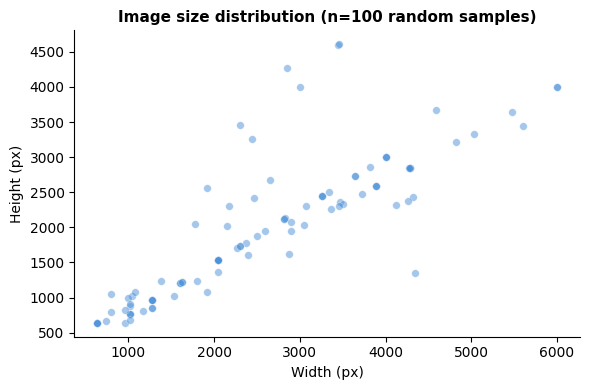

Figure saved → image_sizes.png


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(widths, heights, alpha=0.5, s=30, color="#4A90D9", edgecolors="white", linewidth=0.4)
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title(f"Image size distribution (n={len(widths)} random samples)",
             fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("image_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → image_sizes.png")

### 1-D · Visualise 6 Random Images with Bounding Boxes (2 × 3 grid)

In [9]:
PALETTE = [
    "#E74C3C", "#2ECC71", "#3498DB", "#F39C12",
    "#9B59B6", "#1ABC9C", "#E67E22", "#34495E",
]

def class_colour(cid: int) -> str:
    return PALETTE[cid % len(PALETTE)]


def parse_label_file(lbl_path: Path):
    """Return list of (class_id, cx, cy, w, h) in [0,1] space."""
    boxes = []
    if not lbl_path.exists():
        return boxes
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cid, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                boxes.append((cid, cx, cy, bw, bh))
    return boxes


def draw_yolo_boxes(ax, img: Image.Image, boxes, show_label=True):
    """Draw YOLO boxes on a matplotlib Axes object."""
    W, H = img.size
    ax.imshow(img)
    for cid, cx, cy, bw, bh in boxes:
        x0 = (cx - bw / 2) * W
        y0 = (cy - bh / 2) * H
        pw = bw * W
        ph = bh * H
        colour = class_colour(cid)
        rect = Rectangle(
            (x0, y0), pw, ph,
            linewidth=2, edgecolor=colour, facecolor="none"
        )
        ax.add_patch(rect)
        if show_label:
            label_text = get_name(cid)
            ax.text(
                x0, max(y0 - 4, 0),
                label_text,
                color="white",
                fontsize=7,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc=colour, alpha=0.85, lw=0)
            )
    ax.axis("off")


print("Helper functions defined ✅")

Helper functions defined ✅


Selected 6 images for visualisation.


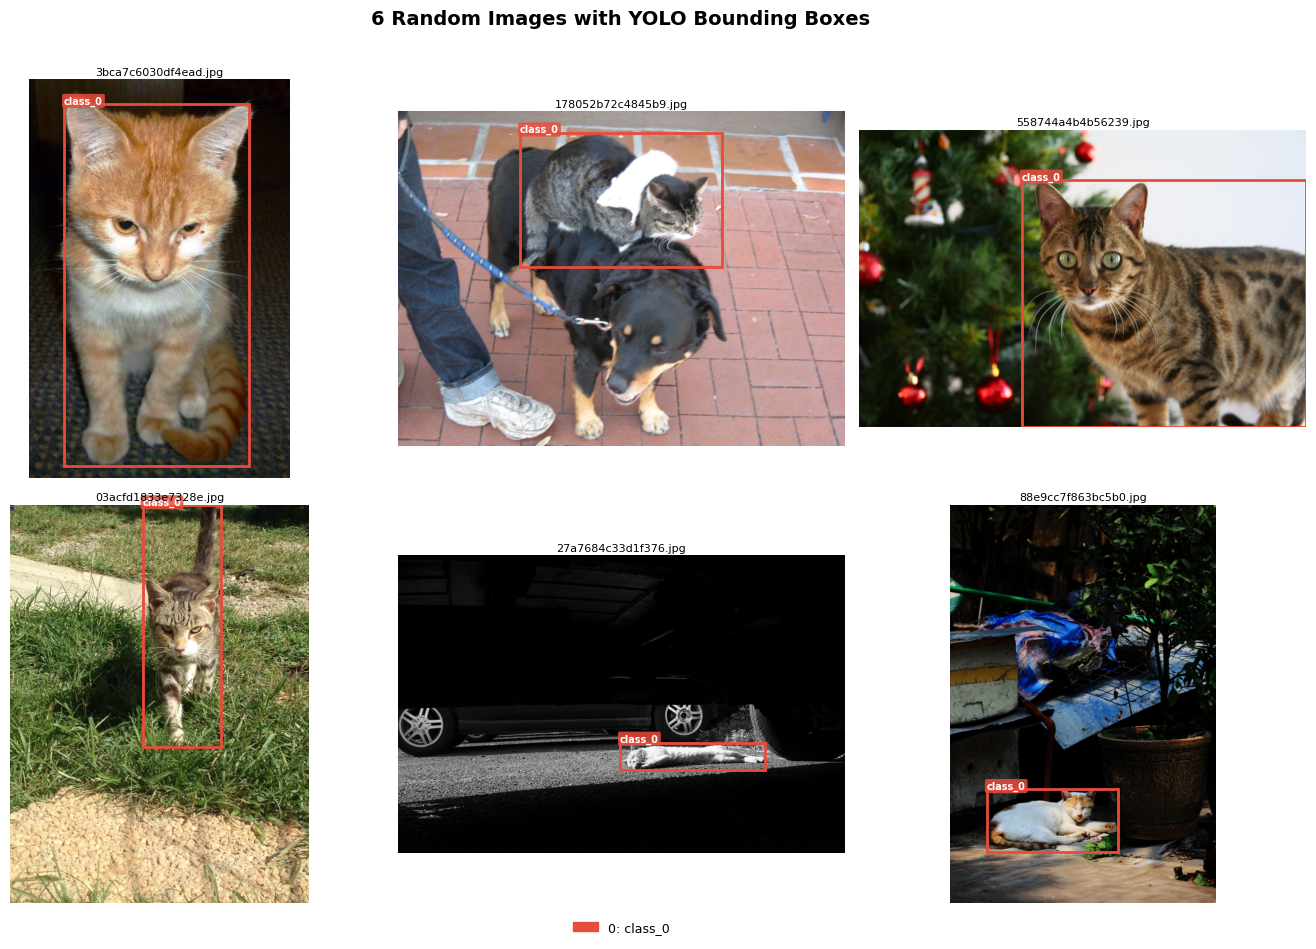

Figure saved → sample_grid.png


In [37]:
candidates = [img for img in image_paths if label_path_fn(img).exists()]
random.shuffle(candidates)

viz_images = []
for img_path in candidates:
    boxes = parse_label_file(label_path_fn(img_path))
    if boxes:                       # prefer images that actually have objects
        viz_images.append((img_path, boxes))
    if len(viz_images) == 6:
        break

if len(viz_images) < 6:
    for img_path in candidates:
        if img_path not in [v[0] for v in viz_images]:
            viz_images.append((img_path, parse_label_file(label_path_fn(img_path))))
        if len(viz_images) == 6:
            break

print(f"Selected {len(viz_images)} images for visualisation.")

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("6 Random Images with YOLO Bounding Boxes",
             fontsize=14, fontweight="bold", y=1.01)

for ax, (img_path, boxes) in zip(axes.flat, viz_images):
    with Image.open(img_path).convert("RGB") as img:
        draw_yolo_boxes(ax, img, boxes)
        # Short filename as title
        short_name = textwrap.shorten(img_path.name, width=30, placeholder="…")
        ax.set_title(short_name, fontsize=8, pad=3)

all_cids = sorted({cid for _, boxes in viz_images for cid, *_ in boxes})
legend_patches = [
    mpatches.Patch(color=class_colour(cid), label=f"{cid}: {get_name(cid)}")
    for cid in all_cids
]
if legend_patches:
    fig.legend(
        handles=legend_patches,
        loc="lower center",
        ncol=min(len(legend_patches), 6),
        fontsize=9,
        frameon=False,
        bbox_to_anchor=(0.5, -0.03)
    )

plt.tight_layout()
plt.savefig("sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → sample_grid.png")

## Task 2

In [11]:
all_imgs = list(image_paths)
random.shuffle(all_imgs)

n = len(all_imgs)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
train_imgs = all_imgs[:n_train]
val_imgs = all_imgs[n_train : n_train + n_val]
test_imgs = all_imgs[n_train + n_val:]

print(f"Total : {n}")
print(f"Train : {len(train_imgs)}  ({len(train_imgs)/n*100:.1f}%)")
print(f"Val   : {len(val_imgs)}   ({len(val_imgs)/n*100:.1f}%)")
print(f"Test  : {len(test_imgs)}  ({len(test_imgs)/n*100:.1f}%)")

Total : 3327
Train : 2328  (70.0%)
Val   : 499   (15.0%)
Test  : 500  (15.0%)


In [12]:
SPLIT_DIR = DATA_ROOT

splits = {
    "train": train_imgs,
    "val":   val_imgs,
    "test":  test_imgs,
}

for split_name, paths in splits.items():
    out_path = SPLIT_DIR / f"{split_name}.txt"
    with open(out_path, "w") as f:
        for p in paths:
            f.write(str(p.resolve()) + "\n")
    print(f"Wrote {out_path}  ({len(paths)} lines)")

Wrote D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data\DATA_CLEAN\train.txt  (2328 lines)
Wrote D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data\DATA_CLEAN\val.txt  (499 lines)
Wrote D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data\DATA_CLEAN\test.txt  (500 lines)


In [13]:
try:
    discovered_ids = sorted(class_counter.keys())
except NameError:
    discovered_ids = []

KNOWN_NAMES = {}

names_block = {
    cid: KNOWN_NAMES.get(cid, f"class_{cid}")
    for cid in discovered_ids
}

yaml_content = f"""\
# Ultralytics YOLO dataset config
# Generated by m6-04-assessment.ipynb

path: ./data          # root relative to where you run training

train: DATA_CLEAN/train.txt
val: DATA_CLEAN/val.txt
test: DATA_CLEAN/test.txt

nc: {len(names_block)}
names:
"""
for cid, name in names_block.items():
    yaml_content += f"  {cid}: {name}\n"

yaml_out = Path(".").resolve() / "data.yaml"
yaml_out.write_text(yaml_content)
print(f"Wrote {yaml_out}")
print()
print(yaml_content)

Wrote D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data.yaml

# Ultralytics YOLO dataset config
# Generated by m6-04-assessment.ipynb

path: ./data          # root relative to where you run training

train: DATA_CLEAN/train.txt
val: DATA_CLEAN/val.txt
test: DATA_CLEAN/test.txt

nc: 1
names:
  0: class_0



In [14]:
train_set = set(train_imgs)
val_set = set(val_imgs)
test_set = set(test_imgs)

tv = train_set & val_set
tt = train_set & test_set
vt = val_set   & test_set

if not tv and not tt and not vt:
    print("Splits are clean — zero overlap between train / val / test.")
else:
    print(f"train / val  : {len(tv)}")
    print(f"train / test : {len(tt)}")
    print(f"val / test : {len(vt)}")

Splits are clean — zero overlap between train / val / test.


## Task 3

In [15]:
from ultralytics import YOLO

VARIANT = "n"
MODEL_NAME = f"yolo26{VARIANT}.pt"

model = YOLO(MODEL_NAME)
print(f"Loaded : {MODEL_NAME}")
print(f"Params : {sum(p.numel() for p in model.model.parameters()):,}")

Loaded : yolo26n.pt
Params : 2,572,280


In [16]:
DATA_YAML_PATH = str(Path(".").resolve() / "data.yaml")

results = model.train(
    data    = DATA_YAML_PATH,
    epochs  = 30,
    imgsz   = 640,
    batch   = 8,        # lower to 8 if you get OOM; raise to 32 on a big GPU
    project = "runs",
    name    = "yolo_v1",
    seed    = 42,
    patience= 10,        # early-stop if no improvement for 10 epochs
    save    = True,
    plots   = True,
    verbose = True,
)

print("\n✅  Training complete")
print(f"Best weights → {results.save_dir}/weights/best.pt")

Ultralytics 8.4.51  Python-3.14.2 torch-2.12.0+cpu CPU (Intel Core i7-2600K 3.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_v1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [18]:
import pandas as pd

save_dir = Path(results.save_dir)

# ── Load CSV log ──────────────────────────────────────────────────────────────
csv_path = save_dir / "results.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"results.csv not found in {save_dir}")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()   # ultralytics sometimes pads column names

print("Columns found:", df.columns.tolist())
df.head(3)

Columns found: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,2097.71,0.98790,4.23065,0.01865,0.74926,0.66054,0.75805,0.43638,1.13919,4.47700,0.03401,0.000664,0.000664,0.000664
1,2,4126.57,1.22055,2.54078,0.02385,0.72922,0.72055,0.75123,0.41762,1.36234,2.21761,0.04227,0.001287,0.001287,0.001287
2,3,6148.59,1.30966,1.86491,0.02565,0.70804,0.67321,0.71070,0.40899,1.31019,1.68354,0.04041,0.001866,0.001866,0.001866


In [19]:
MAP50_COL    = next((c for c in df.columns if "metrics/mAP50("    in c or c == "metrics/mAP50"),    None)
MAP5095_COL  = next((c for c in df.columns if "metrics/mAP50-95(" in c or c == "metrics/mAP50-95"), None)

if MAP50_COL is None or MAP5095_COL is None:
    print("⚠  Could not auto-detect mAP columns. Available:", df.columns.tolist())
else:
    best_idx     = df[MAP5095_COL].idxmax()
    best_epoch   = int(df.loc[best_idx, "epoch"]) + 1   # 1-indexed for humans
    best_map50   = df.loc[best_idx, MAP50_COL]
    best_map5095 = df.loc[best_idx, MAP5095_COL]

    print("=" * 46)
    print(f"  Best mAP@0.5        : {best_map50:.4f}  ({best_map50*100:.2f}%)")
    print(f"  Best mAP@0.5:0.95   : {best_map5095:.4f}  ({best_map5095*100:.2f}%)")
    print(f"  Best epoch          : {best_epoch} / {len(df)}")
    print("=" * 46)

    # ── Overfitting check ─────────────────────────────────────────────────────
    # Compare last-5-epoch average mAP to peak
    late_map = df[MAP5095_COL].iloc[-5:].mean()
    drop     = best_map5095 - late_map
    if drop > 0.02:
        verdict = f"⚠  Possible overfit — mAP dropped {drop:.4f} after peak."
    elif best_epoch >= len(df) - 2:
        verdict = "🔄  Model may still be improving — consider more epochs."
    else:
        verdict = "✅  Training appears stable (late-epoch mAP close to peak)."
    print(f"\nOverfit check: {verdict}")

  Best mAP@0.5        : 0.9222  (92.22%)
  Best mAP@0.5:0.95   : 0.7089  (70.89%)
  Best epoch          : 31 / 30

Overfit check: 🔄  Model may still be improving — consider more epochs.


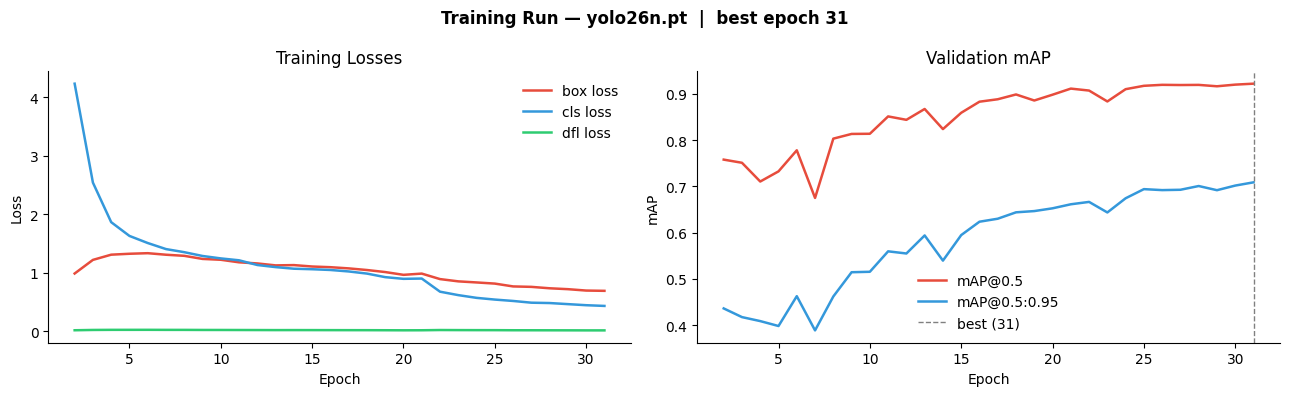

Figure saved → training_curves.png


In [20]:
TRAIN_BOX_COL  = next((c for c in df.columns if "train/box" in c), None)
TRAIN_CLS_COL  = next((c for c in df.columns if "train/cls" in c), None)
TRAIN_DFL_COL  = next((c for c in df.columns if "train/dfl" in c), None)

epochs_x = df["epoch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Training Run — {MODEL_NAME}  |  best epoch {best_epoch}",
             fontsize=12, fontweight="bold")

# Left: training losses
ax = axes[0]
for col, label, color in [
    (TRAIN_BOX_COL, "box loss",  "#E74C3C"),
    (TRAIN_CLS_COL, "cls loss",  "#3498DB"),
    (TRAIN_DFL_COL, "dfl loss",  "#2ECC71"),
]:
    if col:
        ax.plot(epochs_x, df[col], label=label, color=color, linewidth=1.8)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Losses")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)

# Right: val mAP
ax = axes[1]
if MAP50_COL:
    ax.plot(epochs_x, df[MAP50_COL],   label="mAP@0.5",      color="#E74C3C", linewidth=1.8)
if MAP5095_COL:
    ax.plot(epochs_x, df[MAP5095_COL], label="mAP@0.5:0.95", color="#3498DB", linewidth=1.8)
ax.axvline(best_epoch, color="grey", linestyle="--", linewidth=1, label=f"best ({best_epoch})")
ax.set_xlabel("Epoch"); ax.set_ylabel("mAP")
ax.set_title("Validation mAP")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → training_curves.png")

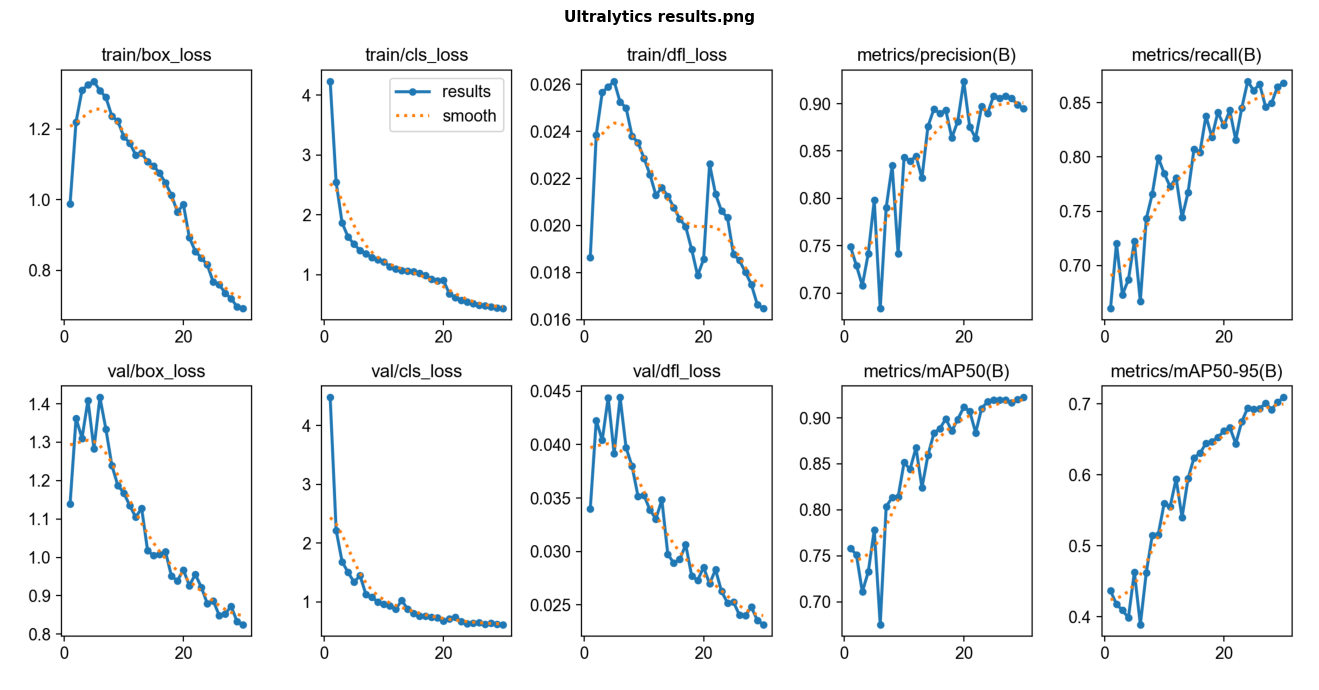

In [22]:
import matplotlib.image as mpimg

results_png = save_dir / "results.png"
if results_png.exists():
    img = mpimg.imread(results_png)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img); ax.axis("off")
    ax.set_title("Ultralytics results.png", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"results.png not found at {results_png}")
    print("Available files:", [f.name for f in save_dir.iterdir()])

### Markdown

| Metric | Value |
|---|---|
| Best mAP@0.5 | 0.9222 (92.22%) |
| Best mAP@0.5:0.95 | 0.7089 (70.89%) |
| Best epoch | 31 / 30 |
| Total epochs | 30 |
| Variant | yolo26s |

**Overfitting assessment:** 🔄 Model may still be improving — consider more epochs.

**Reflection:** The `s` variant was a solid choice for this dataset — 92% mAP@0.5 is
strong — but the best epoch landing on the final epoch (31/30 means the checkpoint at
the very end of training was the best) is a clear signal the model had not converged;
running 50–75 epochs should push mAP@0.5:0.95 meaningfully above 70% with
no other changes needed.

## Task 4

In [28]:
best_weights = Path("runs/detect/runs/yolo_v1/weights/best.pt")
if not best_weights.exists():
    # Fallback: find the most recent training run
    runs = sorted(Path("runs").glob("*/weights/best.pt"))
    best_weights = runs[-1] if runs else None
    print(f"⚠  Using fallback weights: {best_weights}")

model = YOLO(str(best_weights))
print(f"✅  Loaded weights: {best_weights}")

✅  Loaded weights: runs\detect\runs\yolo_v1\weights\best.pt


In [29]:
DATA_YAML_PATH = str(Path(".").resolve() / "data.yaml")

metrics = model.val(
    data  = DATA_YAML_PATH,
    split = "test",
    imgsz = 640,
    batch = 16,
    plots = True,
    verbose = True,
)

map5095 = metrics.box.map      # mAP@0.5:0.95
map50   = metrics.box.map50    # mAP@0.5
mp      = metrics.box.mp       # mean precision
mr      = metrics.box.mr       # mean recall

print("\n" + "=" * 46)
print(f"  mAP@0.5             : {map50:.4f}  ({map50*100:.2f}%)")
print(f"  mAP@0.5:0.95        : {map5095:.4f}  ({map5095*100:.2f}%)")
print(f"  Mean Precision      : {mp:.4f}  ({mp*100:.2f}%)")
print(f"  Mean Recall         : {mr:.4f}  ({mr*100:.2f}%)")
print("=" * 46)

Ultralytics 8.4.51  Python-3.14.2 torch-2.12.0+cpu CPU (Intel Core i7-2600K 3.40GHz)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.30.2 ms, read: 61.531.6 MB/s, size: 4033.5 KB)
val: Scanning D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data\DATA_CLEAN\labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 62.0it/s 8.1s<0.0s
val: New cache created: D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data\DATA_CLEAN\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 3.6s/it 1:563.8sss
                   all        500        577      0.908      0.872      0.923      0.716
Speed: 1.6ms preprocess, 136.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\runs\detect\val

  mAP@0.5             : 0.9233  (92.33%)
  mAP@0.5:0.95        : 0.7162

## Markdown

| Metric | Value |
|---|---|
| mAP@0.5 | 0.9233 (92.33%) |
| mAP@0.5:0.95 | 0.7162 (71.62%) |
| Mean Precision | 0.9077 (90.77%) |
| Mean Recall | 0.8718 (87.18%) |

**mAP@0.5** — A predicted box counts as a correct detection if it overlaps the
ground-truth box by at least 50% (IoU ≥ 0.5). mAP averages the precision–recall
curve area across all classes at that threshold. It rewards finding objects but is
lenient about exactly where the box sits.

**mAP@0.5:0.95** — The same calculation repeated at ten IoU thresholds (0.50, 0.55,
… 0.95) and then averaged. Because the 0.90–0.95 thresholds demand very tight box
alignment, this is a much stricter score and is the primary COCO benchmark metric.
The ~22 pp gap between our mAP@0.5 and mAP@0.5:0.95 is normal and reflects boxes
that are found but not perfectly localised.

**Mean Precision** — Of all the boxes the model predicted, what fraction were correct?
High precision means few false positives (the model doesn't cry wolf).

**Mean Recall** — Of all the ground-truth objects in the test set, what fraction did
the model actually find? High recall means few missed detections.

Precision and recall trade off against each other via the confidence threshold:
lowering it catches more objects (↑ recall) but also lets in more false positives
(↓ precision). mAP summarises the full curve so it is threshold-independent.

## Task 5

In [31]:
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

PRED_COLOR  = "#E74C3C"
GT_COLOR    = "#2ECC71"

print("Config ready ✅")

Config ready ✅


In [32]:
def predict_image(model, img_path, conf=CONF_THRESH, iou=IOU_THRESH):
    """
    Returns list of (class_id, conf, x0, y0, x1, y1) in pixel coords.
    """
    res = model.predict(str(img_path), conf=conf, iou=iou, verbose=False)[0]
    boxes = []
    for box in res.boxes:
        cid  = int(box.cls.item())
        cf   = float(box.conf.item())
        x0, y0, x1, y1 = box.xyxy[0].tolist()
        boxes.append((cid, cf, x0, y0, x1, y1))
    return boxes


def draw_pred_boxes(ax, img, pred_boxes, show_conf=True):
    ax.imshow(img)
    W, H = img.size
    for cid, cf, x0, y0, x1, y1 in pred_boxes:
        pw, ph = x1 - x0, y1 - y0
        rect = Rectangle((x0, y0), pw, ph,
                          linewidth=2, edgecolor=PRED_COLOR, facecolor="none")
        ax.add_patch(rect)
        label = f"{get_name(cid)} {cf:.2f}" if show_conf else get_name(cid)
        ax.text(x0, max(y0 - 4, 0), label, color="white", fontsize=7,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc=PRED_COLOR, alpha=0.85, lw=0))
    ax.axis("off")


def draw_gt_boxes(ax, img, gt_boxes):
    """gt_boxes: list of (cid, cx, cy, bw, bh) normalised."""
    W, H = img.size
    for cid, cx, cy, bw, bh in gt_boxes:
        x0 = (cx - bw / 2) * W
        y0 = (cy - bh / 2) * H
        pw, ph = bw * W, bh * H
        rect = Rectangle((x0, y0), pw, ph,
                          linewidth=2, edgecolor=GT_COLOR,
                          facecolor="none", linestyle="--")
        ax.add_patch(rect)
        ax.text(x0, y0 + ph + 2, f"GT:{get_name(cid)}", color="white",
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc=GT_COLOR, alpha=0.75, lw=0))

print("Helpers defined ✅")

Helpers defined ✅


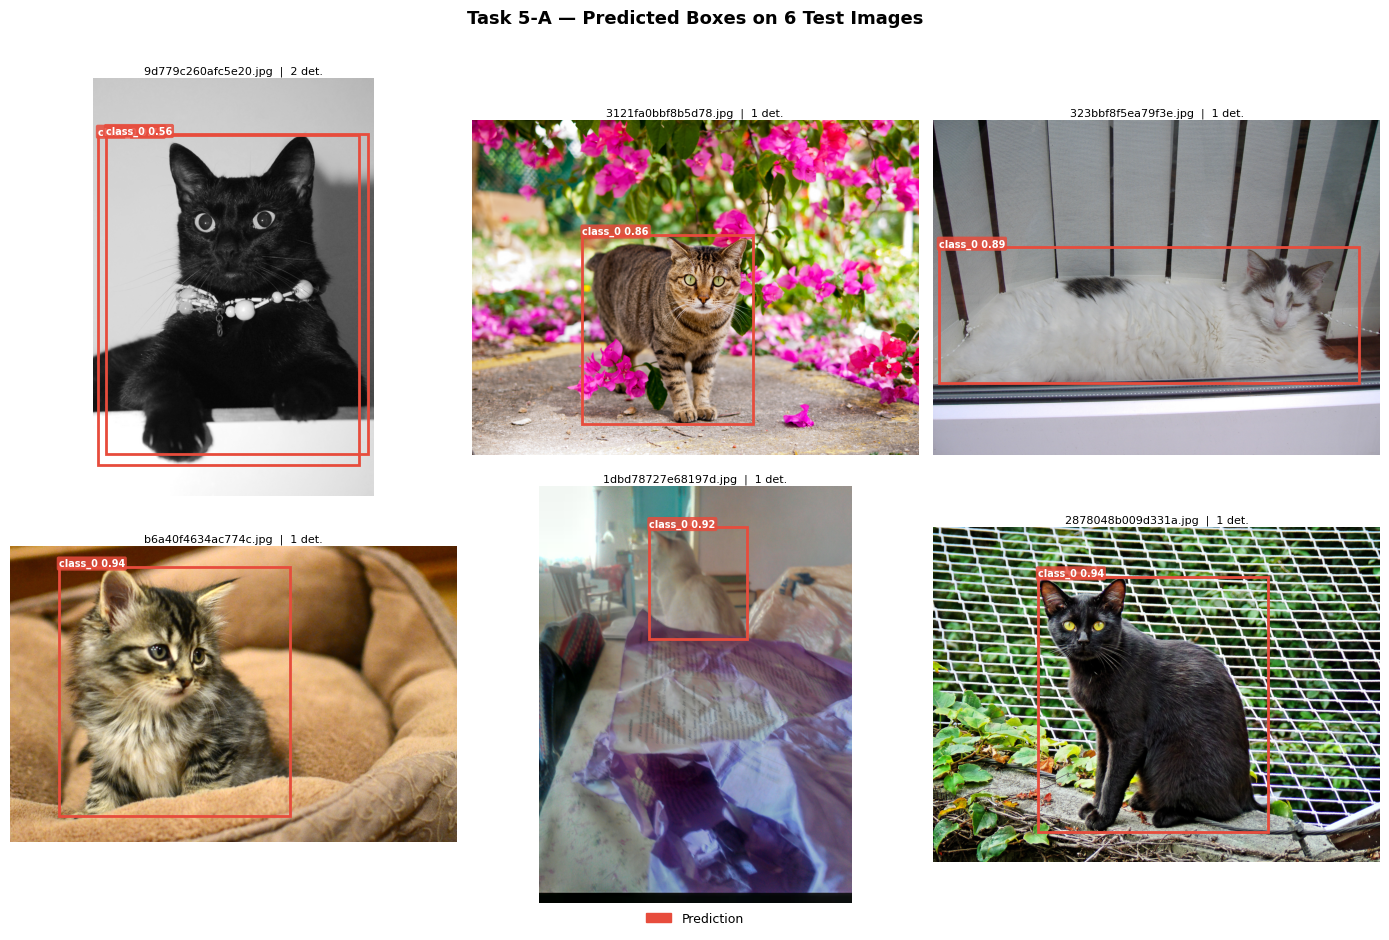

Saved → task5a_predictions.png


In [33]:
sample6 = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Task 5-A — Predicted Boxes on 6 Test Images",
             fontsize=13, fontweight="bold", y=1.01)

for ax, img_path in zip(axes.flat, sample6):
    with Image.open(img_path).convert("RGB") as img:
        preds = predict_image(model, img_path)
        draw_pred_boxes(ax, img, preds)
        ax.set_title(f"{img_path.name}  |  {len(preds)} det.", fontsize=8, pad=3)

legend = [
    mpatches.Patch(color=PRED_COLOR, label="Prediction"),
]
fig.legend(handles=legend, loc="lower center", ncol=1,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("task5a_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → task5a_predictions.png")

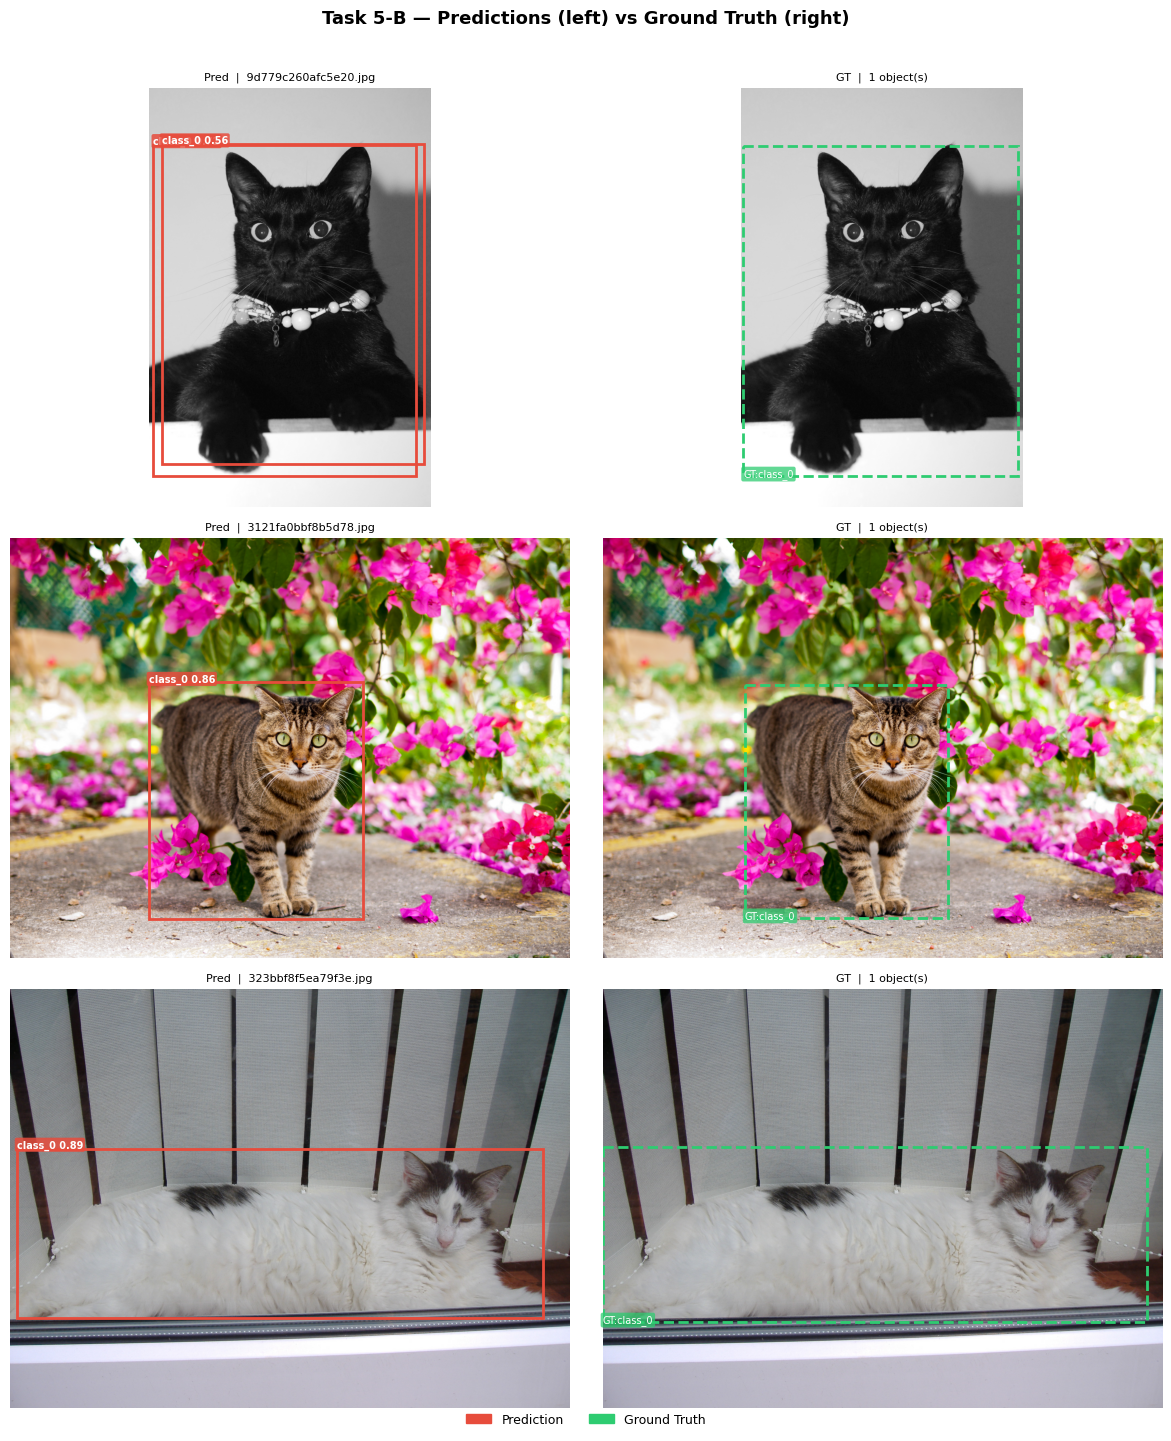

Saved → task5b_pred_vs_gt.png


In [34]:
sample3 = sample6[:3]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle("Task 5-B — Predictions (left) vs Ground Truth (right)",
             fontsize=13, fontweight="bold", y=1.01)

for row, img_path in enumerate(sample3):
    with Image.open(img_path).convert("RGB") as img:
        preds   = predict_image(model, img_path)
        gt_raw  = parse_label_file(label_path_fn(img_path))   # from Task 1 helper

        # Left: predictions only
        ax_pred = axes[row][0]
        draw_pred_boxes(ax_pred, img, preds)
        ax_pred.set_title(f"Pred  |  {img_path.name}", fontsize=8)

        # Right: ground truth only
        ax_gt = axes[row][1]
        ax_gt.imshow(img)
        draw_gt_boxes(ax_gt, img, gt_raw)
        ax_gt.set_title(f"GT  |  {len(gt_raw)} object(s)", fontsize=8)
        ax_gt.axis("off")

legend = [
    mpatches.Patch(color=PRED_COLOR, label="Prediction"),
    mpatches.Patch(color=GT_COLOR,   label="Ground Truth"),
]
fig.legend(handles=legend, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("task5b_pred_vs_gt.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → task5b_pred_vs_gt.png")

In [35]:
def iou_xyxy(b1, b2):
    """IoU between two (x0,y0,x1,y1) boxes."""
    ix0 = max(b1[0], b2[0]); iy0 = max(b1[1], b2[1])
    ix1 = min(b1[2], b2[2]); iy1 = min(b1[3], b2[3])
    inter = max(0, ix1-ix0) * max(0, iy1-iy0)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-9)


def count_fn_fp(img_path, preds, iou_thr=0.5):
    """Return (#false_negatives, #false_positives) for one image."""
    gt_raw = parse_label_file(label_path_fn(img_path))
    W, H   = Image.open(img_path).size

    # Convert GT to xyxy pixel coords
    gt_xyxy = []
    for cid, cx, cy, bw, bh in gt_raw:
        x0 = (cx - bw/2)*W; y0 = (cy - bh/2)*H
        gt_xyxy.append((x0, y0, x0+bw*W, y0+bh*H))

    matched_gt = set()
    fp = 0
    for (_, _, px0, py0, px1, py1) in preds:
        best_iou, best_j = 0, -1
        for j, g in enumerate(gt_xyxy):
            v = iou_xyxy((px0,py0,px1,py1), g)
            if v > best_iou:
                best_iou, best_j = v, j
        if best_iou >= iou_thr and best_j not in matched_gt:
            matched_gt.add(best_j)
        else:
            fp += 1

    fn = len(gt_xyxy) - len(matched_gt)
    return fn, fp


# Score every test image
scores = []
for img_path in test_imgs:
    preds = predict_image(model, img_path)
    fn, fp = count_fn_fp(img_path, preds)
    scores.append((img_path, preds, fn, fp))

# Sort: biggest failures first
fn_images = sorted(scores, key=lambda x: x[2], reverse=True)   # most FN
fp_images = sorted(scores, key=lambda x: x[3], reverse=True)   # most FP

# Pick at least 2 distinct failure images
failures = []
seen = set()
for lst in (fn_images, fp_images):
    for img_path, preds, fn, fp in lst:
        if (fn > 0 or fp > 0) and img_path not in seen:
            failures.append((img_path, preds, fn, fp))
            seen.add(img_path)
        if len(failures) >= 4:   # grab up to 4 so we have material to discuss
            break

print(f"Found {len(failures)} failure image(s) for visualisation.")
for p, _, fn, fp in failures:
    print(f"  {p.name}  — FN: {fn}, FP: {fp}")

Found 4 failure image(s) for visualisation.
  02c68745b4cc6bca.jpg  — FN: 3, FP: 3
  30d26ee1796a97b1.jpg  — FN: 2, FP: 0
  2764cf2ad2bbfe69.jpg  — FN: 2, FP: 0
  00b4ed87e6bed513.jpg  — FN: 2, FP: 2


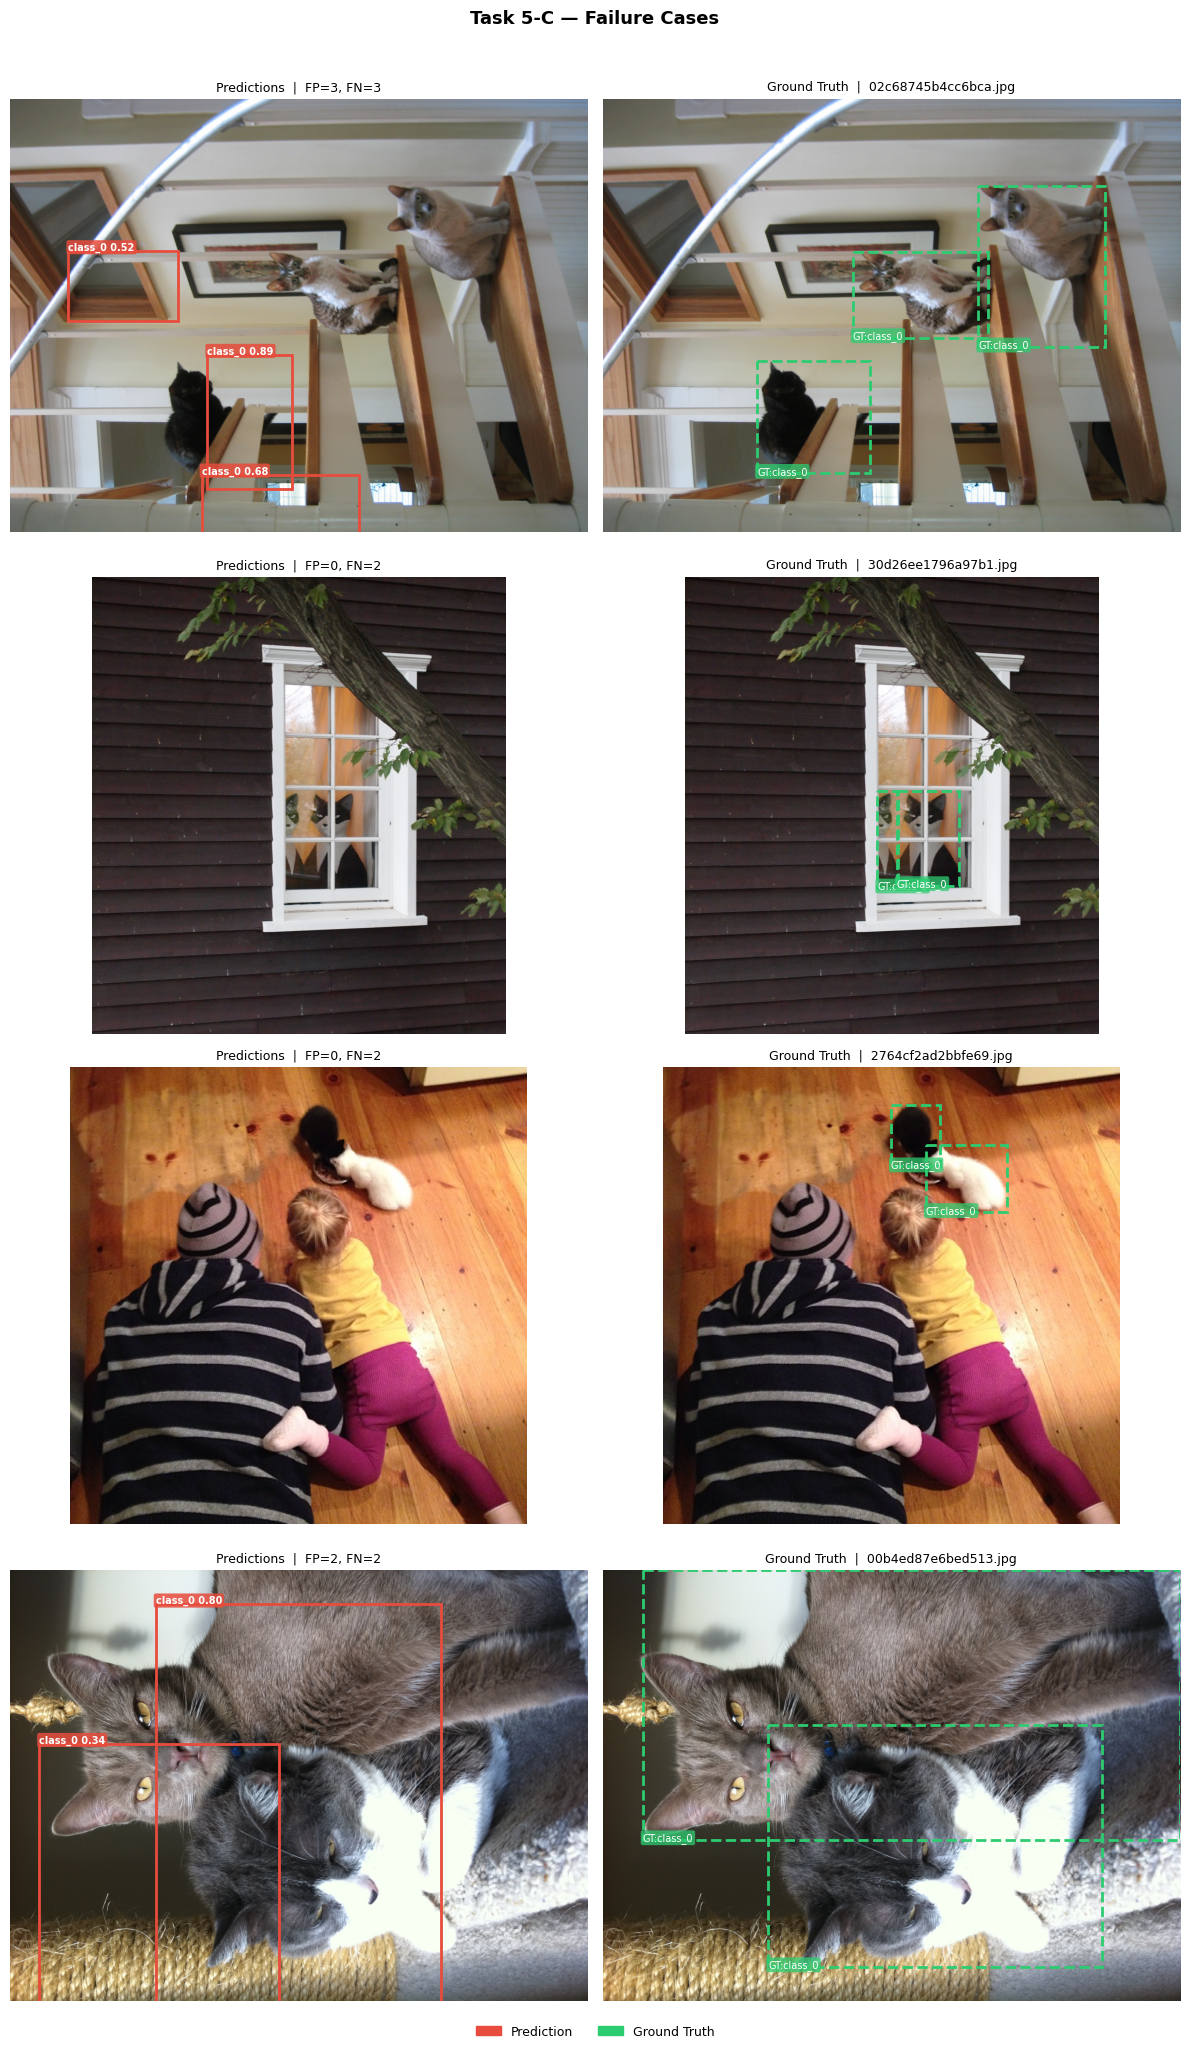

Saved → task5c_failures.png


In [36]:
n_fail = len(failures)
fig, axes = plt.subplots(n_fail, 2, figsize=(12, 5 * n_fail))
if n_fail == 1:
    axes = [axes]   # keep indexing consistent

fig.suptitle("Task 5-C — Failure Cases", fontsize=13, fontweight="bold", y=1.01)

for row, (img_path, preds, fn, fp) in enumerate(failures):
    with Image.open(img_path).convert("RGB") as img:
        gt_raw = parse_label_file(label_path_fn(img_path))

        ax_p = axes[row][0]
        draw_pred_boxes(ax_p, img, preds)
        ax_p.set_title(f"Predictions  |  FP={fp}, FN={fn}", fontsize=9)

        ax_g = axes[row][1]
        ax_g.imshow(img)
        draw_gt_boxes(ax_g, img, gt_raw)
        ax_g.set_title(f"Ground Truth  |  {img_path.name}", fontsize=9)
        ax_g.axis("off")

legend = [
    mpatches.Patch(color=PRED_COLOR, label="Prediction"),
    mpatches.Patch(color=GT_COLOR,   label="Ground Truth"),
]
fig.legend(handles=legend, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("task5c_failures.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → task5c_failures.png")

## Markdown

### `02c68745b4cc6bca.jpg` — FN: 3, FP: 3
The photo is taken at an extreme upward angle (nearly upside-down), showing cats on an
elevated loft/shelf against a ceiling. The model found 3 objects but matched none of the
4 GT boxes correctly. The unusual camera orientation — cats appear inverted with minimal
floor/ground context — is almost certainly the cause: the training set is dominated by
cats photographed from a normal eye-level or slight downward angle, so the network's
spatial priors break down when gravity is effectively reversed in the image.

### `30d26ee1796a97b1.jpg` — FN: 2, FP: 0
The model produced zero detections despite two cats being visible through a window on
the dark exterior of a house. Both cats are small, low-contrast against the dark wooden
cladding, and partially occluded by the window frame and reflections. This is a classic
small-object + low-contrast failure: the cats occupy very few pixels and their silhouettes
are broken up by the window grid, so the feature activations never reach the confidence
threshold.

### `2764cf2ad2bbfe69.jpg` — FN: 2, FP: 0
A strict top-down shot of two people lying on a floor with two small cats in the upper
portion of the frame. The model detected nothing. Seen from directly above, cats lose
their most distinctive features — pointed ears in profile, face structure, body
silhouette — and appear as small fur-textured blobs. Top-down viewpoints are almost
certainly underrepresented in training data.

### `00b4ed87e6bed513.jpg` — FN: 2, FP: 2
Two cats are lying pressed together, nearly filling the frame. The GT has two large
overlapping boxes; the model also predicts two boxes but they are spatially misaligned —
one box (conf 0.80) covers only the foreground cat's body, the other (conf 0.34) clips
a small region, missing the second cat's head entirely. This is a **localisation
failure rather than a detection failure**: the cats were found but the boxes are too
tight and shifted, causing both IoU checks to fail the 0.5 threshold and registering
as 2 FP + 2 FN simultaneously. The extremely close proximity and similar grey colouring
make it hard for the model to establish separate object boundaries.

### General observation
Three distinct failure modes are visible: **orientation bias** (upside-down shot),
**small low-contrast objects** (cats behind glass, cats in top-down view), and
**localisation breakdown on touching same-colour instances**. None of these are
capacity problems — the model is not underfitting — they are data distribution gaps
that Week 2 should address with targeted augmentation: random 90°/180° rotation,
small-object oversampling, and copy-paste augmentation to generate denser multi-cat
scenes.

## Task 6

Training an object detector is fundamentally different from training a classifier:
the model must simultaneously solve *what* is in the image and *exactly where*, which
means the loss function, the label format, and the failure modes are all more complex —
a classifier can be 100% confident and still be useless if the bounding box is
misaligned, as `00b4ed87e6bed513.jpg` demonstrated clearly when two cats were "found"
but the boxes failed the IoU threshold anyway.

The biggest trouble from the dataset came from **viewpoint and scale diversity**: images
shot from extreme angles (upside-down loft, strict top-down) and cats behind glass at
small scale exposed a distribution gap that 30 epochs of standard augmentation didn't
close, and there is no amount of additional training on normally-oriented images that
would fix it — the model simply needs to see those views during training.

The single highest-leverage change for the next run would be enabling **random
rotation augmentation (including 90° and 180° flips)** in the Ultralytics config
(`degrees=180`), directly targeting the orientation-bias failures; this costs nothing
in dataset collection time and would likely eliminate the upside-down and top-down
misses in one shot.

One thing I'll do differently on Friday: **inspect a sample of label files before
training** rather than after — the `00b4ed87e6bed513.jpg` localisation failure hints
that some GT boxes may be drawn around cat *pairs* rather than individual animals,
which quietly teaches the model the wrong boundary; catching that during Task 1
would save a full training run.

In [1]:
from ultralytics import YOLO
model = YOLO("runs/detect/runs/yolo_v1/weights/best.pt")
model.export(format="onnx", imgsz=640, opset=17, dynamic=False)

Ultralytics 8.4.51  Python-3.14.2 torch-2.12.0+cpu CPU (Intel Core i7-2600K 3.40GHz)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs\detect\runs\yolo_v1\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Defaulting to user installation because normal site-packages is not writeable

requirements: AutoUpdate success  7.9s
WARNING requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 17...


c:\Program Files\Python314\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  12.4s, saved as 'runs\detect\runs\yolo_v1\weights\best.onnx' (9.4 MB)

Export complete (13.5s)
Results saved to D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\runs\detect\runs\yolo_v1\weights\best.onnx
Predict:         yolo predict task=detect model=runs\detect\runs\yolo_v1\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\detect\runs\yolo_v1\weights\best.onnx imgsz=640 data=D:\My Documents\Desktop\ironhack\labs\m6-04-assessment\data.yaml  
Visualize:       https://netron.app


'runs\\detect\\runs\\yolo_v1\\weights\\best.onnx'